## O sistema hospitalar enfrenta desafios logísticos na distribuição de medicamentos e insumos.

### Este projeto implementa um algoritmo genético para resolver uma variante do
### Vehicle Routing Problem (VRP), considerando:

- capacidade de veículos
- autonomia
- prioridade de entregas
- custo operacional

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os

sys.path.append(os.path.abspath("src"))
from tsp.genetic_algorithm import run_ga
from tsp.population import population_diversity
from tsp.fitness import fitness_function

from vrp.genetic_algorithm import run_ga_vrp
from vrp.population import population_diversity_vrp
from vrp.fitness import fitness_function_vrp

In [2]:
destinos = pd.read_csv("data/destinos.csv")
deliveries = pd.read_csv("data/deliveries.csv")
vehicles = pd.read_csv("data/vehicles.csv")

#### Análise e visualização de dados

In [4]:
destinos.info()
destinos.head()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          100 non-null    int64
 1   x           100 non-null    int64
 2   y           100 non-null    int64
 3   prioridade  100 non-null    int64
 4   demanda_kg  100 non-null    int64
 5   tipo        100 non-null    str  
 6   horario     100 non-null    str  
dtypes: int64(5), str(2)
memory usage: 5.6 KB


,id,x,y,prioridade,demanda_kg,tipo,horario
0,0,152,130,0,0,central,24h
1,1,485,441,1,7,hospital,comercial
2,2,320,212,1,9,hospital,comercial
3,3,156,468,1,3,casa,24h
4,4,121,338,1,6,casa,comercial


In [5]:
deliveries.info()
deliveries.head()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               99 non-null     str    
 1   destino_id       99 non-null     int64  
 2   peso_kg          99 non-null     float64
 3   descricao        99 non-null     str    
 4   valor_declarado  99 non-null     float64
dtypes: float64(2), int64(1), str(2)
memory usage: 4.0 KB


,id,destino_id,peso_kg,descricao,valor_declarado
0,DELIV_001,1,4.76,Medicamentos/Vacinas,3673.37
1,DELIV_002,2,22.02,Insumos/Soro/Gaze,822.17
2,DELIV_003,3,4.34,Medicamentos/Vacinas,3025.52
3,DELIV_004,4,15.93,Insumos/Soro/Gaze,4851.05
4,DELIV_005,5,24.56,Insumos/Soro/Gaze,950.03


In [6]:
vehicles.info()
vehicles.head()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             15 non-null     str    
 1   tipo           15 non-null     str    
 2   autonomia_km   15 non-null     int64  
 3   capacidade_kg  15 non-null     int64  
 4   custo_km       15 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 732.0 bytes


,id,tipo,autonomia_km,capacidade_kg,custo_km
0,MOTO_1,moto,150,20,1.0
1,MOTO_2,moto,150,20,1.0
2,MOTO_3,moto,150,20,1.0
3,MOTO_4,moto,150,20,1.0
4,MOTO_5,moto,150,20,1.0


In [3]:
import pandas as pd

def preparar_dados():    
    # 2. Agrupar o peso real das entregas por destino
    # Isso resolve o problema de ter múltiplas entregas para o mesmo hospital
    entregas_agrupadas = deliveries.groupby('destino_id').agg({
        'peso_kg': 'sum',
        'valor_declarado': 'sum'
    }).reset_index()

    # 3. Fazer o "Join" (Merge) com a tabela de destinos
    # Como se fosse um LEFT JOIN no SQL
    df_completo = pd.merge(
        destinos, 
        entregas_agrupadas, 
        left_on='id', 
        right_on='destino_id', 
        how='left'
    )

    # 4. Tratar destinos sem entrega (como a base/id 0) preenchendo com 0
    df_completo['peso_kg'] = df_completo['peso_kg'].fillna(0)
    df_completo['valor_declarado'] = df_completo['valor_declarado'].fillna(0)

    return df_completo

# Uso:
df_processado = preparar_dados()
df_processado.head()

,id,x,y,prioridade,demanda_kg,tipo,horario,destino_id,peso_kg,valor_declarado
0,0,152,130,0,0,central,24h,NaN,0.00,0.00
1,1,485,441,1,7,hospital,comercial,1.0,4.76,3673.37
2,2,320,212,1,9,hospital,comercial,2.0,22.02,822.17
3,3,156,468,1,3,casa,24h,3.0,4.34,3025.52
4,4,121,338,1,6,casa,comercial,4.0,15.93,4851.05


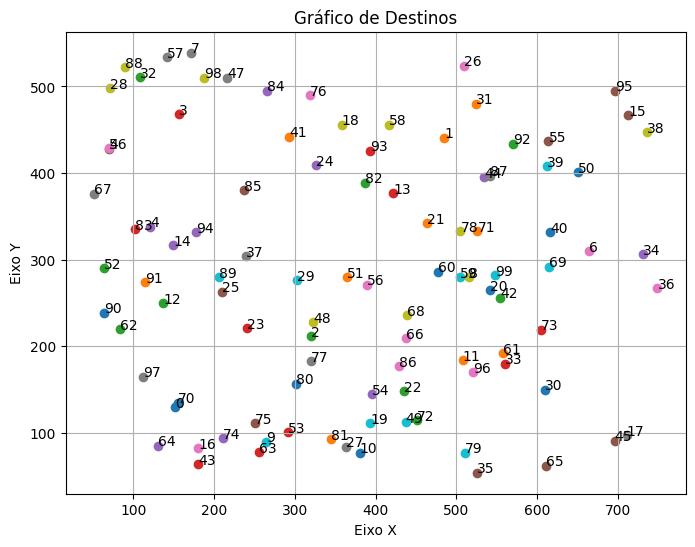

In [7]:
plt.figure(figsize=(8, 6)) # Define o tamanho da imagem

for _, row in destinos.iterrows():
    plt.scatter(row["x"], row["y"])
    plt.text(row["x"], row["y"], row["id"])

plt.xlabel("Eixo X")
plt.ylabel("Eixo Y")
plt.title("Gráfico de Destinos")
plt.grid(True) # Opcional: adiciona uma grade para facilitar a leitura
plt.show()

### Algoritmo Genético para Otimização de Rotas

O algoritmo genético (Genetic Algorithm - GA) é uma técnica de otimização inspirada
no processo de evolução natural.

Neste projeto, o GA é utilizado para encontrar a melhor rota de distribuição
de medicamentos e insumos médicos, minimizando o custo logístico e respeitando
restrições como capacidade do veículo, autonomia e prioridade das entregas.

Cada indivíduo da população representa uma possível rota de entrega.

A evolução das soluções ocorre através de operadores genéticos como seleção,
crossover e mutação, que iterativamente melhoram a qualidade das rotas
avaliadas pela função fitness.

### Pipeline do Algoritmo Genético

O processo de otimização segue as seguintes etapas:

1. **População inicial**
   - Geração aleatória de possíveis rotas de entrega.

2. **Seleção**
   - Seleção das melhores rotas com base na função fitness.

3. **Crossover**
   - Combinação de duas rotas para gerar novas soluções.

4. **Mutação**
   - Pequenas alterações aleatórias nas rotas para manter diversidade.

5. **Avaliação (Fitness)**
   - Cálculo do custo total da rota considerando distância, capacidade
     do veículo, autonomia e prioridade de entregas.

6. **Nova geração**
   - Formação de uma nova população com indivíduos mais adaptados.

Esse processo se repete por várias gerações até que uma solução ótima
ou próxima do ótimo seja encontrada.

### Solução TSP

Geração 49 | Melhor fitness: 1068348.3700218576
Geração 49 | Melhor fitness: 1051195.6575879722
Geração 49 | Melhor fitness: 1042225.120134351
Geração 99 | Melhor fitness: 1037059.2153105196
Geração 49 | Melhor fitness: 1081182.9011776308
Geração 49 | Melhor fitness: 1058920.370670498
Geração 49 | Melhor fitness: 1045093.4321828668
Geração 99 | Melhor fitness: 1035212.4083555585
Geração 49 | Melhor fitness: 1071885.8169704652
Geração 49 | Melhor fitness: 1055645.2441177724
Geração 49 | Melhor fitness: 1043197.1318517398
Geração 99 | Melhor fitness: 1034746.1094377295


,population,generations,mutation,best_fitness
0,50,50,0.01,1.068348e+06
1,100,50,0.01,1.051196e+06
2,200,50,0.01,1.042225e+06
3,200,100,0.01,1.037059e+06
4,50,50,0.05,1.081183e+06
5,100,50,0.05,1.058920e+06
6,200,50,0.05,1.045093e+06
7,200,100,0.05,1.035212e+06
8,50,50,0.10,1.071886e+06
9,100,50,0.10,1.055645e+06


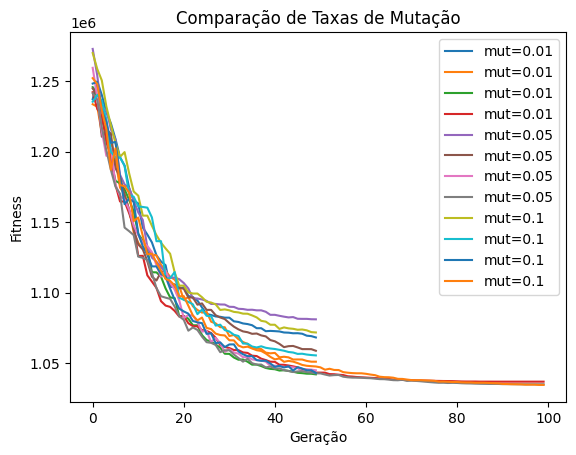

In [6]:
## Selecao de veículo para visualizar ga
vehicle = vehicles.iloc[0]

## Testes a serem executados
experiments = [
    {"pop":50, "gen":50, "mut":0.01},
    {"pop":100, "gen":50, "mut":0.01},
    {"pop":200, "gen":50, "mut":0.01},
    {"pop":200, "gen":100, "mut":0.01},
    
    {"pop":50, "gen":50, "mut":0.05},
    {"pop":100, "gen":50, "mut":0.05},
    {"pop":200, "gen":50, "mut":0.05},
    {"pop":200, "gen":100, "mut":0.05},
    
     {"pop":50, "gen":50, "mut":0.1},
    {"pop":100, "gen":50, "mut":0.1},
    {"pop":200, "gen":50, "mut":0.1},
    {"pop":200, "gen":100, "mut":0.1},
]

results = []
population_history = []

for exp in experiments:

    route, history, population = run_ga(
        df_processado,
        vehicle,
        pop_size=exp["pop"],
        generations=exp["gen"],
        mutation_rate=exp["mut"]
    )
    
    # grafico comparacao historico de taxa de mutacao
    plt.plot(history, label=f"mut={exp['mut']}")

    # montando conteudo para tabela explicativa
    results.append({
        "population": exp["pop"],
        "generations": exp["gen"],
        "mutation": exp["mut"],
        "best_fitness": history[-1]
    })
    
    # adicionando conteudo para comparacao da taxa de variacao da populacao
    population_history.append(population.copy())
plt.legend()
plt.title("Comparação de Taxas de Mutação")
plt.xlabel("Geração")
plt.ylabel("Fitness")

df_results = pd.DataFrame(results)
df_results



Text(0, 0.5, 'Diversidade')

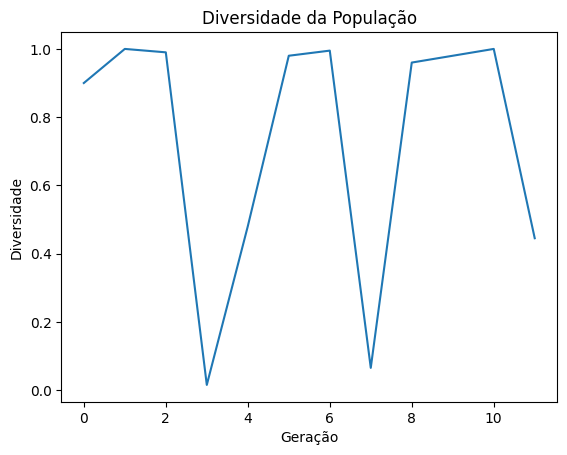

In [7]:


diversity_history = [
    population_diversity(pop)
    for pop in population_history
]

plt.plot(diversity_history)
plt.title("Diversidade da População")
plt.xlabel("Geração")
plt.ylabel("Diversidade")

In [8]:
fitness_scores = [
    fitness_function(ind, destinos, vehicle)
    for ind in population
]

plt.hist(fitness_scores, bins=20)
plt.title("Distribuição de Fitness")

KeyError: 'peso_kg'

In [2]:
sorted_pop = sorted(
    population,
    key=lambda ind: fitness_function(ind, destinos, vehicle)
)

top_5 = sorted_pop[:5]

NameError: name 'population' is not defined

### Solução VRP

Geração 99 | Best: 1075415.9977303885


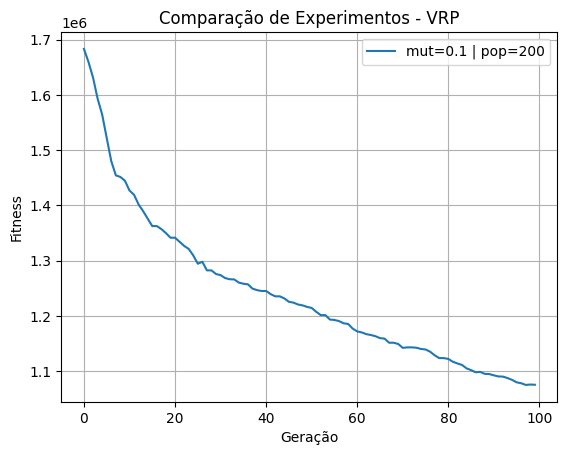

,population,generations,mutation,best_fitness,avg_fitness,std_fitness,min_fitness
0,200,100,0.1,1.075416e+06,1.240334e+06,137943.873891,1.075128e+06


In [6]:
## Testes a serem executados
experiments = [
    # {"pop":50, "gen":50, "mut":0.01},
    # {"pop":100, "gen":50, "mut":0.01},
    # {"pop":200, "gen":50, "mut":0.01},
    # {"pop":200, "gen":100, "mut":0.01},
    
    # {"pop":50, "gen":50, "mut":0.05},
    # {"pop":100, "gen":50, "mut":0.05},
    # {"pop":200, "gen":50, "mut":0.05},
    # {"pop":200, "gen":100, "mut":0.05},
    
    #  {"pop":50, "gen":50, "mut":0.1},
    # {"pop":100, "gen":50, "mut":0.1},
    # {"pop":200, "gen":50, "mut":0.1},
    {"pop":200, "gen":100, "mut":0.1},
]

results = []
population_history = []
fitness_histories = []

for exp in experiments:

    best_routes, history, population = run_ga_vrp(
        df_processado,
        vehicles,  # 🔥 agora correto
        pop_size=exp["pop"],
        generations=exp["gen"],
        mutation_rate=exp["mut"]
    )

    fitness_histories.append(history)

    # gráfico comparativo
    plt.plot(history, label=f"mut={exp['mut']} | pop={exp['pop']}")

    # tabela
    results.append({
        "population": exp["pop"],
        "generations": exp["gen"],
        "mutation": exp["mut"],
        "best_fitness": history[-1],
        "avg_fitness": np.mean(history),
        "std_fitness": np.std(history),
        "min_fitness": np.min(history)
    })

    population_history.append(population.copy())

plt.legend()
plt.title("Comparação de Experimentos - VRP")
plt.xlabel("Geração")
plt.ylabel("Fitness")
plt.grid()
plt.show()

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by="best_fitness")

df_results

Inicialmente foi implementado um algoritmo genético para resolver
o problema do caixeiro viajante (TSP), considerando apenas um
veículo responsável por todas as entregas.

Posteriormente, o modelo foi expandido para o problema de
roteamento de veículos (VRP), permitindo múltiplos veículos
com diferentes capacidades e autonomias.

Essa extensão torna o modelo mais realista e adequado ao
contexto logístico hospitalar.